# Melting Point 예측 AI 모델
중간시험 과제 — XGBoost + RDKit Morgan Fingerprint

In [36]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn xgboost rdkit optuna

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 13.3 MB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ----- ---------------------------------- 1/7 [Mako]
   ----------- ---------------------------- 2/7 [greenlet]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ------------------

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드

In [38]:
df = pd.read_csv('../data/Melting_point_2.csv')
print(f'데이터 크기: {df.shape}')
print(f'결측치: {df.isnull().sum().sum()}')
df.head()

데이터 크기: (2189, 2)
결측치: 0


,SMILES,MP
0,CCN(O)CC,247.650
1,c1(C(C)=C)ccccc1,249.950
2,C/C=C/CCCC,164.000
3,c1(CC)cc(CC)cc(CC)c1,206.735
4,COC(C)(C)C(=O)OC,229.600


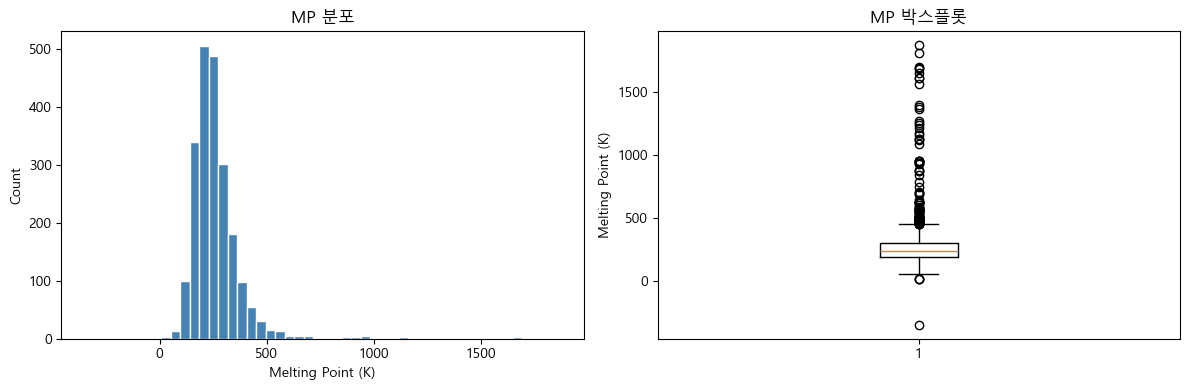

count    2189.000000
mean      267.673160
std       155.797744
min      -348.000000
25%       193.000000
50%       240.100000
75%       297.150000
max      1870.000000
Name: MP, dtype: float64


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MP'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Melting Point (K)')
axes[0].set_ylabel('Count')
axes[0].set_title('MP 분포')

axes[1].boxplot(df['MP'])
axes[1].set_ylabel('Melting Point (K)')
axes[1].set_title('MP 박스플롯')

plt.tight_layout()
plt.show()

print(df['MP'].describe())

## 2. 피처 엔지니어링 — Morgan Fingerprint + RDKit Descriptors

In [40]:
# MorganGenerator (최신 API)
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_features(smiles_list):
    """
    SMILES → Morgan Fingerprint (2048-bit) + RDKit 분자 기술자 10종
    파싱 불가 SMILES는 건너뜀
    """
    records, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        fp = np.array(morgan_gen.GetFingerprintAsNumPy(mol), dtype=np.float32)

        desc = np.array([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumRotatableBonds(mol),
            rdMolDescriptors.CalcNumRings(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol),
            Descriptors.FractionCSP3(mol),
            Descriptors.HeavyAtomCount(mol),
        ], dtype=np.float32)

        records.append(np.concatenate([fp, desc]))
        valid_idx.append(i)

    return np.array(records), valid_idx


print('피처 추출 중...')
X_all, valid_idx = smiles_to_features(df['SMILES'].tolist())
y_all = df['MP'].values[valid_idx]

print(f'유효 샘플: {len(valid_idx)} / {len(df)}')
print(f'피처 차원: {X_all.shape[1]}  (Morgan 2048 + 기술자 10)')

피처 추출 중...
유효 샘플: 2189 / 2189
피처 차원: 2058  (Morgan 2048 + 기술자 10)


## 3. Train / Test 분할 (8:2)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]}개  |  Test: {X_test.shape[0]}개')

Train: 1751개  |  Test: 438개


## 4. 하이퍼파라미터 튜닝 (Optuna Bayesian Optimization)

In [42]:
def objective(trial):
    params = {
        'max_depth':             trial.suggest_int('max_depth', 2, 5),
        'min_child_weight':      trial.suggest_int('min_child_weight', 5, 30),
        'reg_alpha':             trial.suggest_float('reg_alpha', 1.0, 20.0, log=True),
        'reg_lambda':            trial.suggest_float('reg_lambda', 5.0, 50.0, log=True),
        'subsample':             trial.suggest_float('subsample', 0.4, 0.7),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.3, 0.5),
        'learning_rate':         trial.suggest_float('learning_rate', 0.005, 0.02, log=True),
        'n_estimators':          2000,
        'early_stopping_rounds': 50,
        'tree_method':           'hist',
        'random_state':          RANDOM_STATE,
        'n_jobs':                -1,
        'verbosity':             0,
    }
    kf_opt = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in kf_opt.split(X_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        m = xgb.XGBRegressor(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        scores.append(r2_score(y_val, m.predict(X_val)))
    return float(np.mean(scores) - 0.5 * np.std(scores))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params.copy()
best_params.update({
    'n_estimators': 2000,
    'early_stopping_rounds': 50,
    'tree_method': 'hist',
    'verbosity': 0,
    'n_jobs': -1,
    'random_state': RANDOM_STATE,
})
print('Best CV score (mean-0.5*std):', round(study.best_value, 4))
print('Best params:', best_params)


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV score (mean-0.5*std): 0.4953
Best params: {'max_depth': 3, 'min_child_weight': 5, 'reg_alpha': 2.0726913075891864, 'reg_lambda': 15.906069688490819, 'subsample': 0.6485241004944584, 'colsample_bytree': 0.4146676797921973, 'learning_rate': 0.015163650126799643, 'n_estimators': 2000, 'early_stopping_rounds': 50, 'tree_method': 'hist', 'verbosity': 0, 'n_jobs': -1, 'random_state': 42}


## 5. 모델 정의 — Best Params 적용

In [43]:
model = xgb.XGBRegressor(**best_params)
print('모델 정의 완료')
print('파라미터:', best_params)

모델 정의 완료
파라미터: {'max_depth': 3, 'min_child_weight': 5, 'reg_alpha': 2.0726913075891864, 'reg_lambda': 15.906069688490819, 'subsample': 0.6485241004944584, 'colsample_bytree': 0.4146676797921973, 'learning_rate': 0.015163650126799643, 'n_estimators': 2000, 'early_stopping_rounds': 50, 'tree_method': 'hist', 'verbosity': 0, 'n_jobs': -1, 'random_state': 42}


## 6. 5-Fold Cross Validation

In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2, cv_mse, cv_mae = [], [], []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    fold_model = xgb.XGBRegressor(**best_params)
    fold_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    pred = fold_model.predict(X_val)

    cv_r2.append(r2_score(y_val, pred))
    cv_mse.append(mean_squared_error(y_val, pred))
    cv_mae.append(mean_absolute_error(y_val, pred))
    print(f'Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.2f}  MAE={cv_mae[-1]:.2f}')

print()
print('=== 5-Fold CV 평균 ===')
print(f'R²  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}')
print(f'MSE : {np.mean(cv_mse):.2f} ± {np.std(cv_mse):.2f}')
print(f'MAE : {np.mean(cv_mae):.2f} ± {np.std(cv_mae):.2f}')

Fold 1  R²=0.5902  MSE=11365.54  MAE=48.50
Fold 2  R²=0.6155  MSE=11381.50  MAE=41.66
Fold 3  R²=0.4680  MSE=9719.25  MAE=50.16
Fold 4  R²=0.4148  MSE=19826.45  MAE=53.46
Fold 5  R²=0.5847  MSE=5918.62  MAE=43.33

=== 5-Fold CV 평균 ===
R²  : 0.5346 ± 0.0787
MSE : 11642.27 ± 4551.56
MAE : 47.42 ± 4.36


## 6. 최종 모델 — 전체 Train 재학습 후 Test 평가

In [45]:
X_tr, X_val_final, y_tr, y_val_final = train_test_split(
    X_train, y_train, test_size=0.1, random_state=RANDOM_STATE
)
model.fit(X_tr, y_tr, eval_set=[(X_val_final, y_val_final)], verbose=False)

y_pred = model.predict(X_test)

test_r2  = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print('=== Test Set 성능 ===')
print(f'R²  : {test_r2:.4f}')
print(f'MSE : {test_mse:.2f}')
print(f'MAE : {test_mae:.2f}')

=== Test Set 성능 ===
R²  : 0.4831
MSE : 11427.89
MAE : 53.06


## 7. 시각화

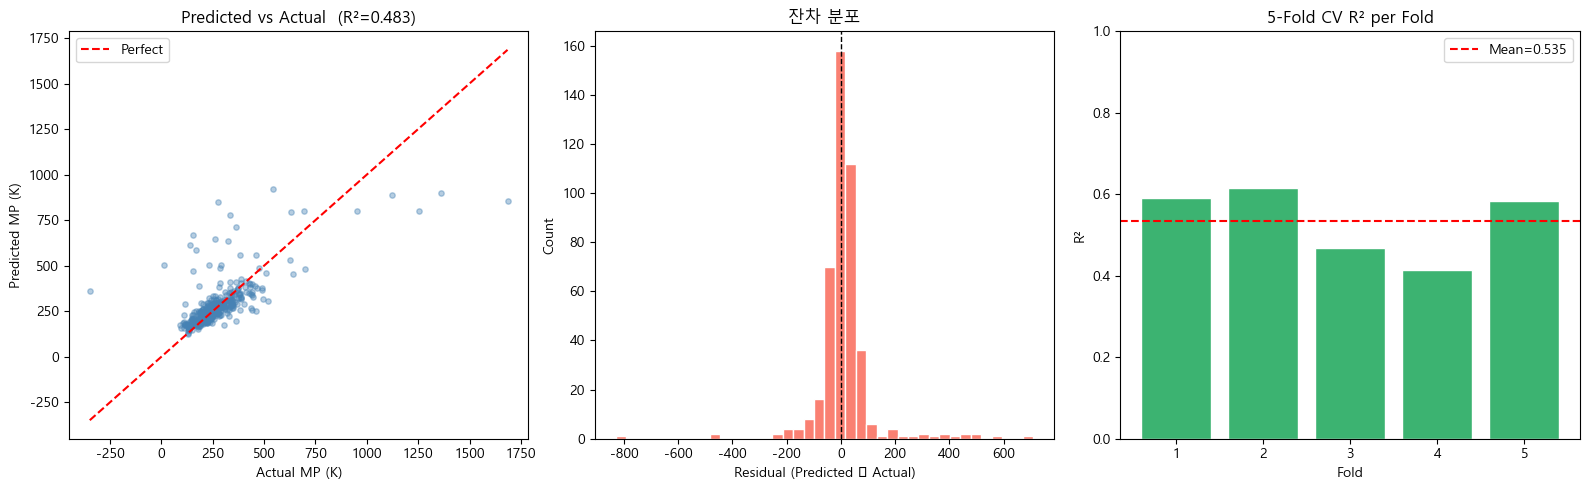

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
ax.set_xlabel('Actual MP (K)')
ax.set_ylabel('Predicted MP (K)')
ax.set_title(f'Predicted vs Actual  (R²={test_r2:.3f})')
ax.legend()

# Residual Distribution
ax = axes[1]
residuals = y_pred - y_test
ax.hist(residuals, bins=40, color='salmon', edgecolor='white')
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('Residual (Predicted − Actual)')
ax.set_ylabel('Count')
ax.set_title('잔차 분포')

# 5-Fold CV R²
ax = axes[2]
ax.bar(range(1, 6), cv_r2, color='mediumseagreen', edgecolor='white')
ax.axhline(np.mean(cv_r2), color='red', linestyle='--', label=f'Mean={np.mean(cv_r2):.3f}')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_title('5-Fold CV R² per Fold')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

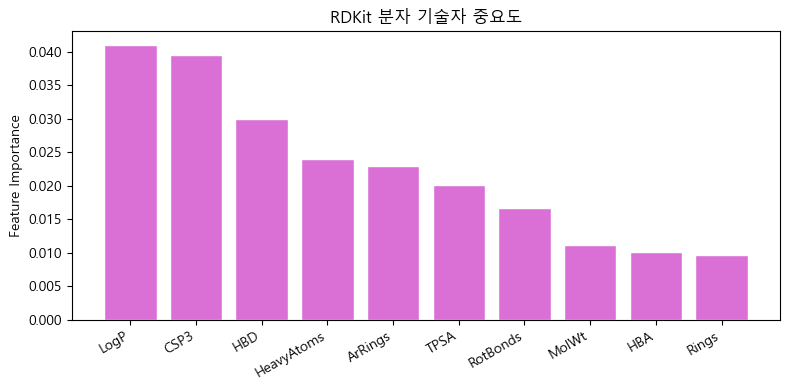

In [47]:
# 분자 기술자 중요도 (상위 10개)
desc_names = [
    'MolWt', 'LogP', 'HBD', 'HBA', 'TPSA',
    'RotBonds', 'Rings', 'ArRings', 'CSP3', 'HeavyAtoms'
]
desc_imp = model.feature_importances_[-10:]
sorted_idx = np.argsort(desc_imp)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(10), desc_imp[sorted_idx], color='orchid', edgecolor='white')
plt.xticks(range(10), [desc_names[i] for i in sorted_idx], rotation=30, ha='right')
plt.ylabel('Feature Importance')
plt.title('RDKit 분자 기술자 중요도')
plt.tight_layout()
plt.show()

## 8. 결과 요약 (레포트용)

In [48]:
summary = pd.DataFrame({
    '구분': ['5-Fold CV 평균', 'Test Set'],
    'R²' : [f"{np.mean(cv_r2):.4f}", f"{test_r2:.4f}"],
    'MSE': [f"{np.mean(cv_mse):.2f}", f"{test_mse:.2f}"],
    'MAE': [f"{np.mean(cv_mae):.2f}", f"{test_mae:.2f}"],
})
summary

,구분,R²,MSE,MAE
0,5-Fold CV 평균,0.5346,11642.27,47.42
1,Test Set,0.4831,11427.89,53.06
